# **Results Comparison**

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
folder_path = 'model_metrics'    

In [11]:
def open_json(folder_path):
    all_data = []
    for file in os.listdir(folder_path):
        if file.endswith('.json'):
            with open(os.path.join(folder_path, file), 'r') as f:
                data = json.load(f)
                all_data.append(data)
    
    return all_data

metrics = open_json(folder_path)
print(metrics)


[{'model': 'NN', 'configuration': 'LSTM', 'accuracy': 0.5778688524590164, 'precision': 0.5210355987055016, 'recall': 0.5, 'f1_score': 0.5103011093502378, 'auc': 0.5695121884346008, 'timestamp': '2026-03-14 23:39:21'}, {'model': 'NN', 'configuration': 'NN', 'accuracy': 0.5683060109289617, 'precision': 0.5104166666666666, 'recall': 0.45652173913043476, 'f1_score': 0.4819672131147541, 'auc': 0.5563096404075623, 'timestamp': '2026-03-14 23:38:57'}]


In [12]:
df = pd.DataFrame(metrics)

In [13]:
df.head()

,model,configuration,accuracy,precision,recall,f1_score,auc,timestamp
0,NN,LSTM,0.577869,0.521036,0.500000,0.510301,0.569512,2026-03-14 23:39:21
1,NN,NN,0.568306,0.510417,0.456522,0.481967,0.556310,2026-03-14 23:38:57


Comparison Graphs

In [14]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "auc"]

df_long = df.melt(
    id_vars="configuration",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="value"
)

print(df_long.head())

  configuration     metric     value
0          LSTM   accuracy  0.577869
1            NN   accuracy  0.568306
2          LSTM  precision  0.521036
3            NN  precision  0.510417
4          LSTM     recall  0.500000


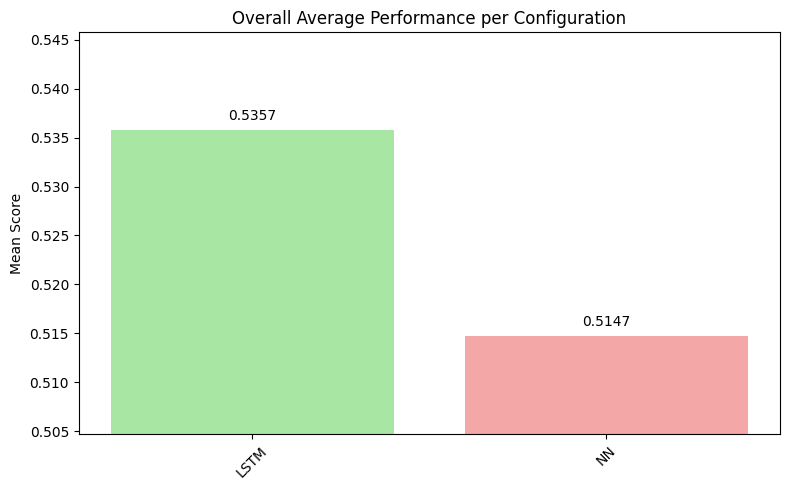

In [15]:

# Compute mean score
df["mean_score"] = df[["accuracy","precision","recall","f1_score","auc"]].mean(axis=1)

# Identify max and min
max_value = df["mean_score"].max()
min_value = df["mean_score"].min()

# Pastel color palette
pastel_green = "#A8E6A3"
pastel_red = "#F4A7A7"
pastel_yellow = "#F9E79F"


colors = []

for value in df["mean_score"]:
    if value == max_value:
        colors.append(pastel_green)
    elif value == min_value:
        colors.append(pastel_red)
    else:
        colors.append(pastel_yellow)


plt.figure(figsize=(8,5))

bars = plt.bar(df["configuration"], df["mean_score"], color=colors)

plt.ylim(df["mean_score"].min() - 0.01,
         df["mean_score"].max() + 0.01)

plt.xticks(rotation=45)
plt.ylabel("Mean Score")
plt.title("Overall Average Performance per Configuration")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.001,
             f"{yval:.4f}",
             ha='center',
             fontsize=10)

plt.tight_layout()
plt.show()

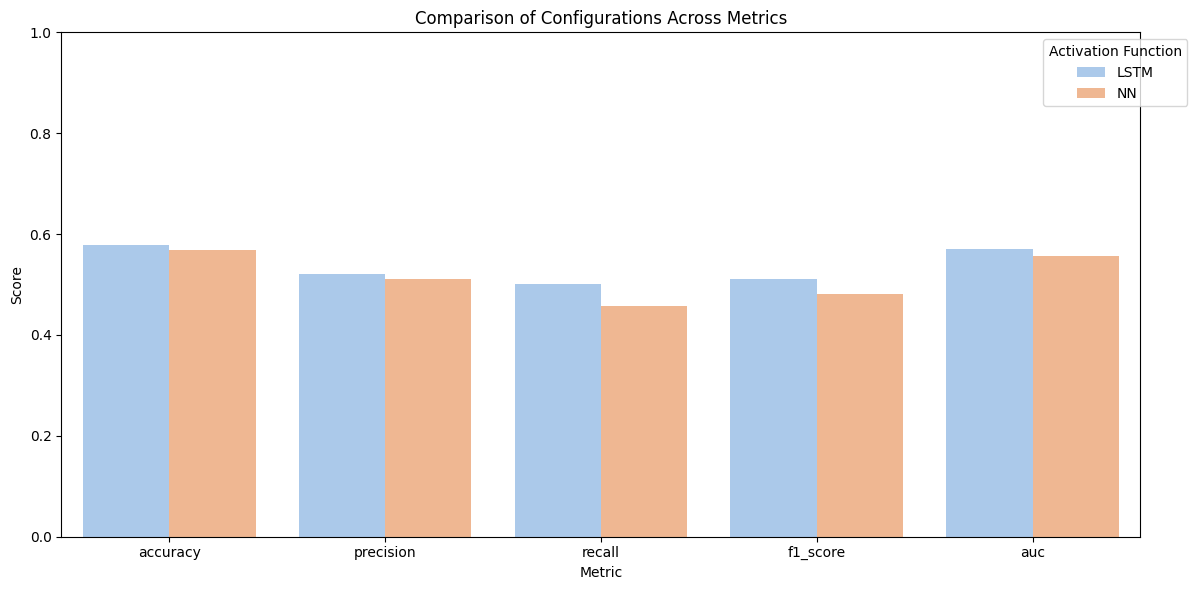

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="configuration",
    palette="pastel")


plt.title("Comparison of Configurations Across Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Activation Function", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

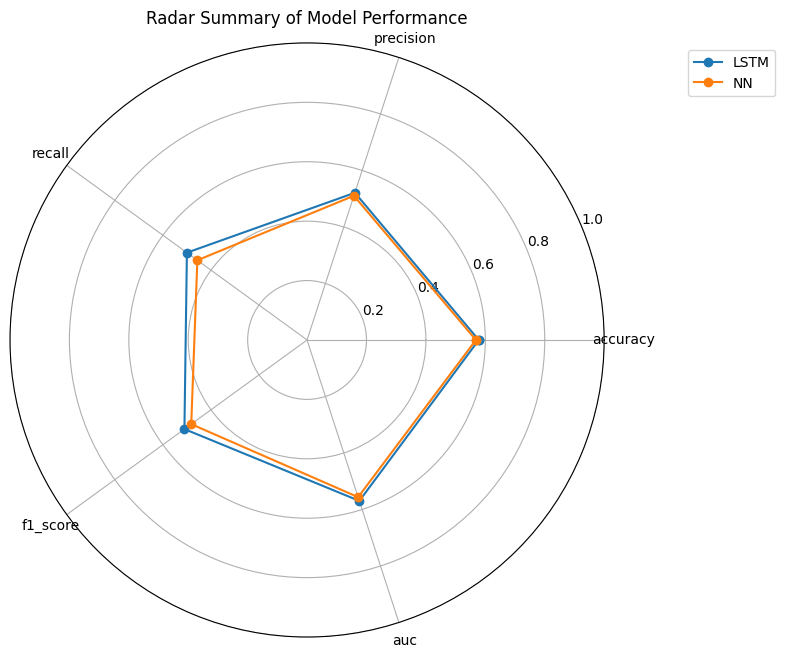

In [17]:


metrics = ["accuracy", "precision", "recall", "f1_score", "auc"]
labels = metrics
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))

for i in range(len(df)):
    values = df.loc[i, metrics].tolist()
    values += values[:1]
    
    plt.polar(angles, values, label=df.loc[i, "configuration"], marker='o')

plt.xticks(angles[:-1], labels)
plt.ylim(0, 1)
plt.title("Radar Summary of Model Performance")
plt.legend(bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()